In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

In [7]:
data = pd.read_csv("../data/bodyfat.csv")
data.head()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


In [8]:
data.describe()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,19.150794,44.884921,178.924405,70.148810,37.992063,100.824206,92.555952,99.904762,59.405952,38.590476,23.102381,32.273413,28.663889,18.229762
std,0.019031,8.368740,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,2.411805,1.694893,3.021274,2.020691,0.933585
min,0.995000,0.000000,22.000000,118.500000,29.500000,31.100000,79.300000,69.400000,85.000000,47.200000,33.000000,19.100000,24.800000,21.000000,15.800000
25%,1.041400,12.475000,35.750000,159.000000,68.250000,36.400000,94.350000,84.575000,95.500000,56.000000,36.975000,22.000000,30.200000,27.300000,17.600000
50%,1.054900,19.200000,43.000000,176.500000,70.000000,38.000000,99.650000,90.950000,99.300000,59.000000,38.500000,22.800000,32.050000,28.700000,18.300000
75%,1.070400,25.300000,54.000000,197.000000,72.250000,39.425000,105.375000,99.325000,103.525000,62.350000,39.925000,24.000000,34.325000,30.000000,18.800000
max,1.108900,47.500000,81.000000,363.150000,77.750000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000


In [9]:
data.iloc[[47, 75, 95, 181]]

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
47,1.0665,5.6,39,148.50,71.25,34.6,89.8,79.5,92.7,52.7,37.5,21.9,28.8,26.8,17.9
75,1.0666,18.5,61,148.25,67.50,36.0,91.6,81.8,94.8,54.5,37.0,21.4,29.3,27.0,18.3
95,1.0991,17.4,53,224.50,77.75,41.1,113.2,99.2,107.5,61.7,42.3,23.2,32.9,30.8,20.4
181,1.1089,0.0,40,118.50,68.00,33.8,79.3,69.4,85.0,47.2,33.5,20.2,27.7,24.6,16.5


In [10]:
def siri_equation(density):
    return (495 / density) - 450

In [11]:
bf_check = siri_equation(data['Density'])
bf_check.iloc[[47, 75, 95, 181]]

47     14.135021
75     14.091506
95      0.368483
181    -3.611687
Name: Density, dtype: float64

In [12]:
difference = data['BodyFat'] - bf_check
difference[difference.abs() > 2]

47     -8.535021
75      4.408494
95     17.031517
181     3.611687
dtype: float64

In [13]:
data.drop([95, 181], inplace=True)
data.loc[47, "BodyFat"] = siri_equation(data.loc[47, "Density"])
data.iloc[[47, 75, 95, 181]]

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
47,1.0665,14.135021,39,148.50,71.25,34.6,89.8,79.5,92.7,52.7,37.5,21.9,28.8,26.8,17.9
75,1.0666,18.500000,61,148.25,67.50,36.0,91.6,81.8,94.8,54.5,37.0,21.4,29.3,27.0,18.3
96,1.0770,9.600000,38,188.75,73.25,37.5,99.1,91.6,102.4,60.6,39.4,22.9,31.6,30.1,18.5
183,1.0713,12.100000,40,159.25,69.75,35.3,92.3,86.8,96.1,58.0,39.4,22.7,30.0,26.4,17.4


<Axes: >

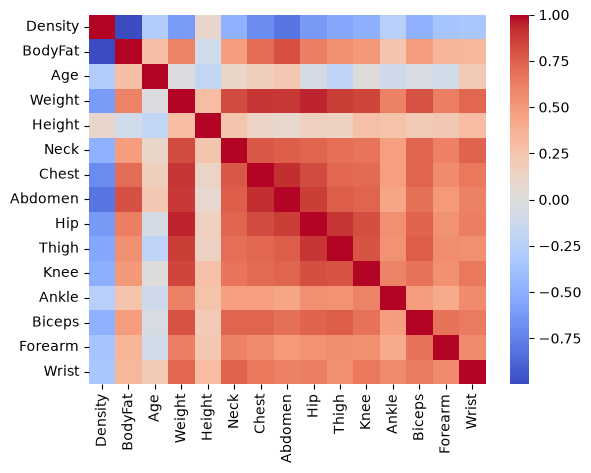

In [18]:
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm')

In [20]:
data['BodyFat'].skew()

np.float64(0.1767283699891579)

<Axes: xlabel='BodyFat', ylabel='Count'>

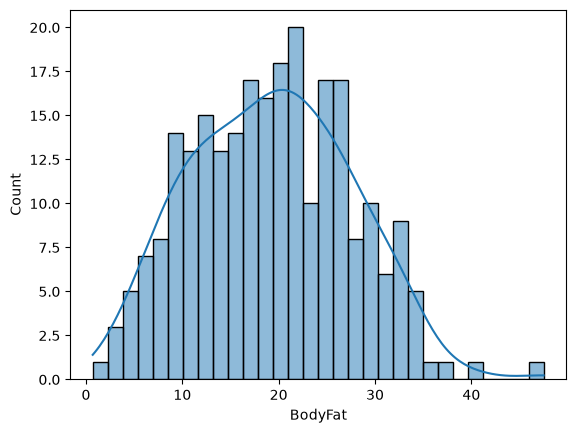

In [21]:
sns.histplot(data['BodyFat'], kde=True, bins=30)